In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# For a good time, call
random.seed(8675309)

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from os import listdir
import os
import random
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


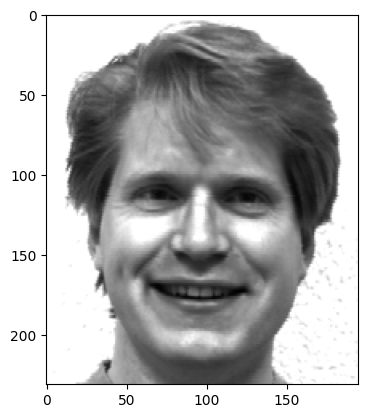

In [ ]:
# Test that images can be opened and displayed
work_path = "/content/drive/MyDrive/DigitalImageProcessing/"
filenames = os.listdir(work_path+ 'Data/centered')
with open(work_path+ "Data/centered/subject01.happy.pgm", "rb") as img:
    picture = plt.imread(img)

plt.imshow(picture, cmap="gray")
plt.show()

(231, 195, 2)
(231, 195, 2)


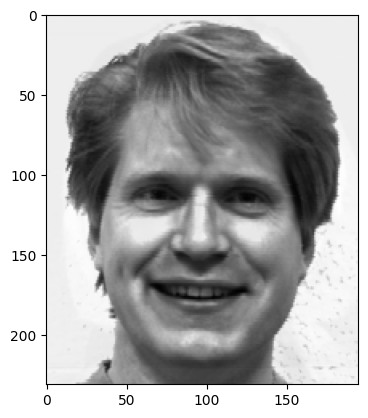

[24.03180125 15.3544424 ]


In [ ]:
class KLTransformer:
    def __init__(self, images):
        self.N, self.img_shape = images.shape[-1], images.shape[:-1]
        t_images = images.reshape(self.img_shape[0] * self.img_shape[1], self.N)
        self.mean = np.expand_dims(np.average(t_images, axis=-1), axis=-1)
        Upsilon = (t_images - self.mean) / np.sqrt(self.N)
        eigvals, Zetta = np.linalg.eigh(Upsilon.transpose() @ Upsilon)
        self.eigvals = np.expand_dims(eigvals, axis=-1)
        self.eigvecs = Upsilon @ Zetta

    def transform(self, images):
        # if len(images.shape) < 3:
        #     images = np.expand_dims(images, axis=-1)
        # assert images.shape[:-1] == self.img_shape
        images = images.reshape(images[:,:,0].size, images.shape[-1]) - self.mean
        return (self.eigvecs.transpose() @ images) / self.eigvals

    def itransform(self, pcs):
        return np.reshape(
            self.eigvecs @ pcs + self.mean, (*self.img_shape, pcs.shape[-1])
        )

    # Return the top p principle components with others set to zero
    def take(self, pcs, p):
        new_pcs = pcs.copy()
        for row, col in enumerate(np.argsort(-np.abs(new_pcs), axis=0)[p:].transpose()):
            new_pcs[col, row] = 0
        return new_pcs


def img2vec(images):
    if len(images.shape) <= 2:
        shape = (images.size, 1)
    else:
        shape = (images[:,:,0].size, images.shape[-1])
    return np.reshape(images, shape)


def imgsnr(actual, estimate):
    return 10 * np.log10(
        np.var(img2vec(actual), axis=0) / np.var(img2vec(actual - estimate), axis=0)
    )


# Generate eigen-images for 15 training samples with the same pose
tset_files = [f"subject{i+1:02}.happy.pgm" for i in range(15)]
tset_images = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in tset_files], axis=-1)
print(tset_images[:,:,:2].shape)

kl = KLTransformer(tset_images)
pcs = kl.transform(tset_images[:,:,:2])
xpcs = kl.take(pcs, 10)
# print(kl.eigvecs[:,0].shape)
# print(np.sum(kl.eigvecs[:,3]))

output_image = kl.itransform(xpcs)
print(output_image.shape)
plt.imshow(output_image[:,:,0], cmap="gray")
plt.show()

print(imgsnr(tset_images[:,:,:2], output_image))

The minimum number of eigenimages for 95% reconstruction is: 13
	[10 12 13 11]


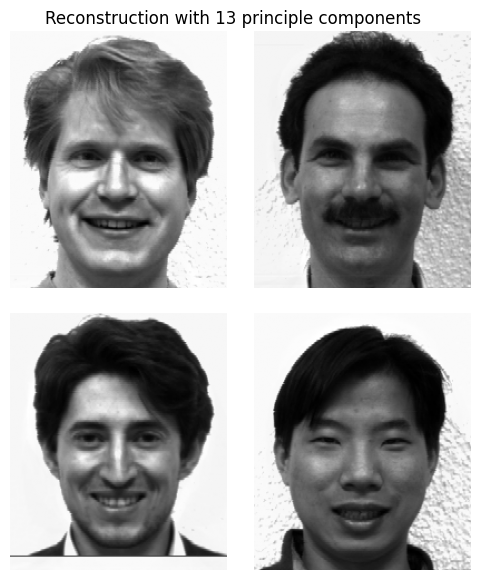

In [ ]:
# Select four training images to evaluate
training_subset = tset_files.copy()
# random.shuffle(training_subset)
subset_images = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in training_subset[:4]], axis=-1)
pcs = kl.transform(subset_images)

# Sort, sum, and normalize the eigenvalues to determine how many must be kept for 95% reconstruction
eigen_sum = np.cumsum(np.sort(np.abs(pcs), axis=0), axis=0)
min_images = np.sum((eigen_sum / eigen_sum[-1]) >0.05, axis= 0)
print(f"The minimum number of eigenimages for 95% reconstruction is: {np.max(min_images)}")
print(f"\t{min_images}")

num_pcs = np.max(min_images)
xpcs = kl.take(pcs, num_pcs)
training_reconstructions = kl.itransform(xpcs)

fig, axs = plt.subplots(2, 2, squeeze=True, figsize=(6,7))
for i, ax in enumerate(axs.flat):
    ax.imshow(training_reconstructions[:,:,i], cmap="gray")
    ax.set_aspect("equal")
    ax.axis("off")
plt.tight_layout
plt.subplots_adjust(wspace=.1, hspace=0.1)
fig.suptitle(f"Reconstruction with {num_pcs} principle components", y=.91)
plt.show()


150


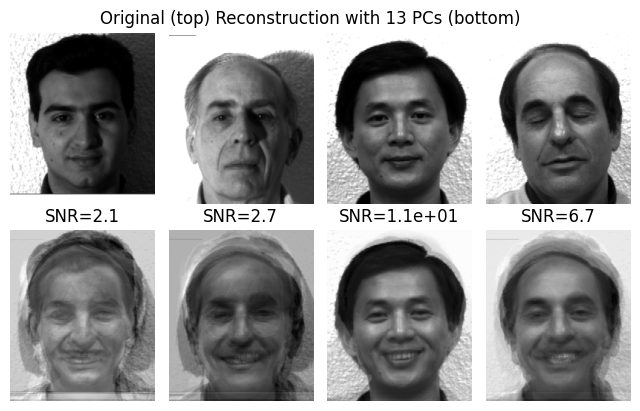

In [ ]:
# Select four test images to evaluate
test_files = list(filter(lambda x: x not in tset_files, os.listdir(work_path+"Data/centered")))
print(len(test_files))
random.shuffle(test_files)
# print(test_files[:4])
# print(test_files)
test_images = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in test_files[:4]], axis=-1)
pcs = kl.transform(test_images)
xpcs = kl.take(pcs, num_pcs)
test_reconstruction = kl.itransform(xpcs)
test_snr = imgsnr(test_images, test_reconstruction)

fig, axs = plt.subplots(2, 4, squeeze=True, figsize=(8,5))
for ax in axs.flat:
    ax.set_aspect("equal")
    ax.axis("off")

for i in range(4):
    axs[0,i].imshow(test_images[:,:,i], cmap="gray")
    axs[1,i].imshow(test_reconstruction[:,:,i], cmap="gray")
    axs[1,i].set_title(f"SNR={test_snr[i]:0.02}", loc="center")
    axs[1,i].title.set_position((0.5, -0.25))
plt.subplots_adjust(wspace=.1, hspace=0.05)
fig.suptitle(f"Original (top) Reconstruction with {num_pcs} PCs (bottom)", y=.91)
plt.show()



The between 65 and 82 eigenimages are required for 95% reconstruction of the training set
65


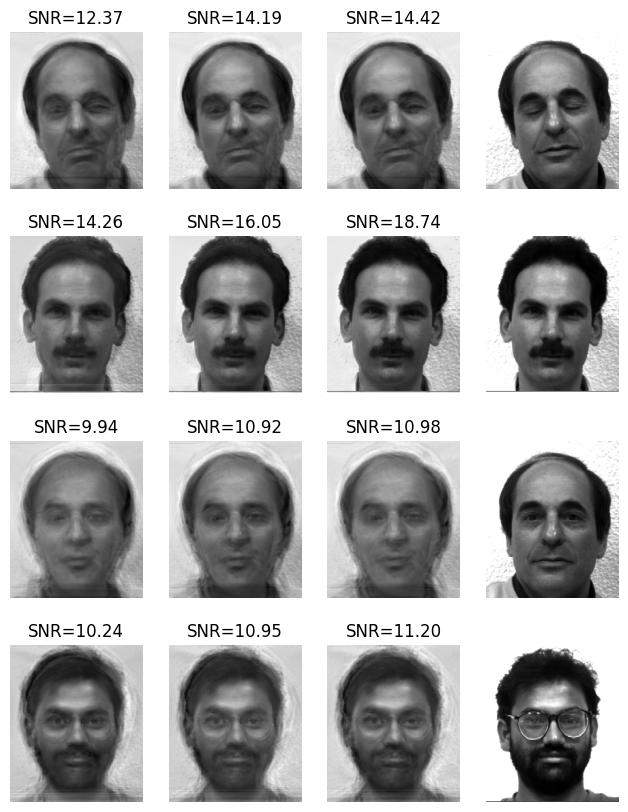

In [ ]:
# Create a KL-Transformer based on 2/3 of the data
all_images = os.listdir(work_path+"Data/centered")
random.shuffle(all_images)
n = len(all_images) * 2 // 3
train_set = all_images[:n]
test_set = all_images[n:]

train_images = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in train_set], axis=-1)
test_images = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in test_set], axis=-1)

kl_66 = KLTransformer(train_images)
train_pcs = kl_66.transform(train_images)
eigen_sum = np.cumsum(np.sort(np.abs(train_pcs), axis=0), axis=0)
min_images = np.sum((eigen_sum / eigen_sum[-1]) >0.05, axis= 0)
print(f"The between {np.min(min_images)} and {np.max(min_images)} eigenimages are required for 95% reconstruction of the training set")
print(np.min(min_images))

test_pcs = kl_66.transform(test_images)
test_xpcs = kl_66.take(test_pcs, 86)
test_reconst = kl_66.itransform(test_xpcs)

# fig, axes = plt.subplots(1, 2)
# axes[0].imshow(test_reconst[:,:,0], cmap="gray")
# axes[1].imshow(test_images[:,:,0], cmap="gray")
# plt.show()

img_count = 4
reconst_count = [50,75,100]
fig, axes = plt.subplots(len(reconst_count) + 1, img_count, figsize=(8,10))
for ax in axes.flat:
    ax.set_aspect("equal")
    ax.axis("off")

for i, n in enumerate(reconst_count):
    x_imgs = kl_66.itransform(kl_66.take(test_pcs, n))
    x_snr = imgsnr(test_images, x_imgs)
    for j in range(img_count):
        axes[j,i].imshow(x_imgs[:,:,j], cmap="gray")
        axes[j,i].set_title(f"SNR={x_snr[j]:.2f}")

for j in range(img_count):
    axes[j,-1].imshow(test_images[:,:,j], cmap="gray")

plt.subplots_adjust(wspace=.1, hspace=0.3)
plt.show()





Text(0, 0.5, 'SNR (dB)')

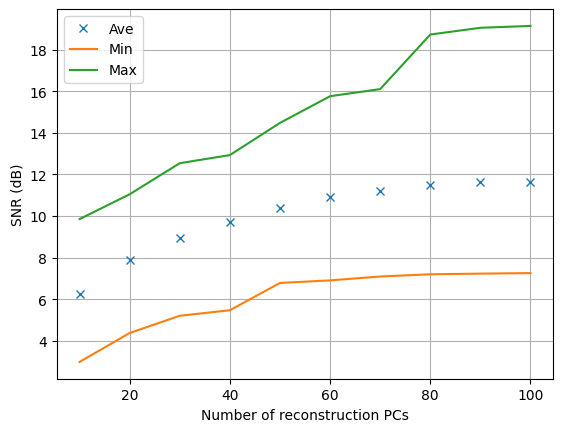

In [ ]:
xn_pcs = np.arange(10,110,10)
snr_vals = []
for n in xn_pcs:
    snr_vals.append(imgsnr(test_images, kl_66.itransform(kl_66.take(test_pcs, n))))

snr_vals = np.stack(snr_vals)
plt.plot(xn_pcs, np.average(snr_vals, axis=-1), "x", label="Ave")
plt.plot(xn_pcs, np.min(snr_vals, axis=-1), label="Min")
plt.plot(xn_pcs, np.max(snr_vals, axis=-1), label="Max")
plt.grid()
plt.legend()
plt.xlabel("Number of reconstruction PCs")
plt.ylabel("SNR (dB)")

(231, 195, 2)


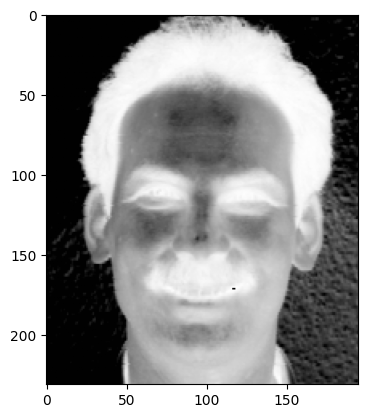

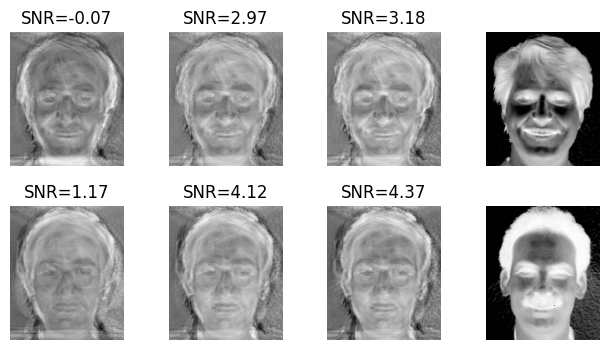

In [ ]:
# Modified cell UPqczWTS3Mde
# subjects = np.stack([plt.imread(work_path+f"Data/subject{i+1:02}.*.pgm")[:,:,0] for i in range(2)], axis=-1)
# subjects = plt.imread("alt/subject01.png")

# List the specific files you want to load
file_list = [
    work_path + "Data/centered/subject01.happy.pgm",
    work_path + "Data/centered/subject02.happy.pgm"
]

subjects = np.stack([plt.imread(f) for f in file_list], axis=-1)

subjects = (subjects * 255).astype(np.uint8)
print(subjects.shape)
plt.imshow(subjects[:,:,1], cmap="gray")
plt.show()
alt_pcs = kl_66.transform(subjects)
# print(alt_pcs.shape)
# plt.imshow(kl_66.itransform(alt_pcs)[:,:,1], cmap="gray")
# plt.show()

img_count = 2
reconst_count = [50,75,100]
fig, axes = plt.subplots(img_count, len(reconst_count) + 1, figsize=(8,4))
for ax in axes.flat:
    ax.set_aspect("equal")
    ax.axis("off")

for i, n in enumerate(reconst_count):
    x_imgs = kl_66.itransform(kl_66.take(alt_pcs, n))
    x_snr = imgsnr(subjects, x_imgs)
    for j in range(img_count):
        axes[j,i].imshow(x_imgs[:,:,j], cmap="gray")
        axes[j,i].set_title(f"SNR={x_snr[j]:.2f}")

for j in range(img_count):
    axes[j,-1].imshow(subjects[:,:,j], cmap="gray")

plt.subplots_adjust(wspace=.1, hspace=0.3)
plt.show()

61.199999999999996
66.60000000000001
0.9520504188329523
0.8950418984606252


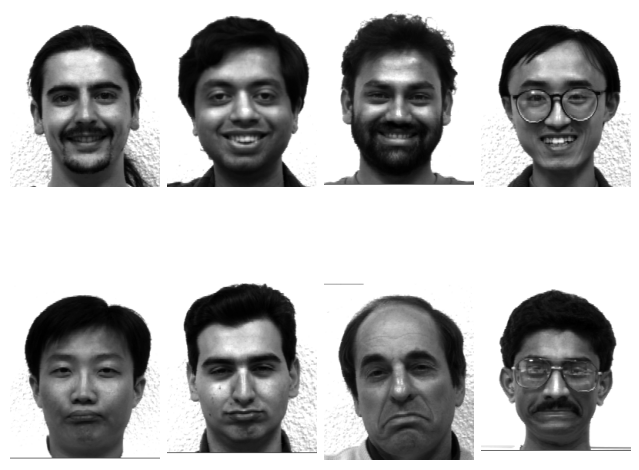

In [ ]:
# Classifier study
glasses_files = [f"subject{n + 1:02}.happy.pgm" for n in range(15)]
noglasses_files = [f"subject{n + 1:02}.sad.pgm" for n in range(15)]
selections = np.arange(len(glasses_files))
glasses_accuracy = []
noglasses_accuracy = []
for i in range(200):
    random.shuffle(selections)

    im_glasses = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in glasses_files], axis=-1)
    im_noglasses = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in noglasses_files], axis=-1)
    # im_glasses = im_glasses[selections]
    # im_noglasses = im_noglasses[selections]
    training_N = 10 # (15 + 15) * 2/3
    training_class_data = np.concatenate([im_glasses[:,:,:training_N], im_noglasses[:,:,:training_N]], axis=-1)
    #print(training_class_data.shape)

    training_class_data = [training_class_data[:,:,i] for i in range(training_class_data.shape[-1])]
    #print(training_class_data[0].shape)
    random.shuffle(training_class_data)
    training_class_data = np.stack(training_class_data, axis=-1)
    #print(training_class_data.shape)
    kl_classifier = KLTransformer(training_class_data)

    # Calculate the centroids of the two classes
    glasses_centroid = np.expand_dims(np.mean(kl_classifier.transform(im_glasses[:,:,:training_N]),axis=-1), axis=-1)
    noglasses_centroid = np.expand_dims(np.mean(kl_classifier.transform(im_noglasses[:,:,:training_N]),axis=-1), axis=-1)

    def classify(images):
        pcs = kl_classifier.transform(images)
        return np.argmin(np.stack([np.sum((glasses_centroid - pcs)**2, axis=0), np.sum((noglasses_centroid - pcs)**2, axis=0)]), axis=0)

    # print(glasses_centroid)
    # print(noglasses_centroid)
    test_glasses = im_glasses[:,:,training_N:]
    # print(np.sum(classify(test_glasses) == 0)/5)
    test_noglasses = im_noglasses[:,:,training_N:]
    # print(np.sum(classify(test_noglasses) == 1)/5)
    glasses_accuracy.append(np.sum(classify(test_glasses) == 0))
    noglasses_accuracy.append(np.sum(classify(test_noglasses) == 1))

print(np.mean(glasses_accuracy)/5*100)
print(np.mean(noglasses_accuracy)/5*100)
print(np.std(glasses_accuracy))
print(np.std(noglasses_accuracy))

fig, axs = plt.subplots(2,4, squeeze=True, figsize=(8,7))
for ax in axs.flat:
    ax.set_aspect("equal")
    ax.axis("off")
for i in range(10): # loop 4 times to display 4 images
    axs[0,i%4].imshow(im_glasses[:,:,i], cmap="gray") # use modulo to cycle through columns
    axs[1,i%4].imshow(im_noglasses[:,:,i+5], cmap="gray") # use modulo to cycle through columns
plt.subplots_adjust(wspace=0.05, hspace=0.03)
#fig.suptitle(f"Glasses (top) No Glasses with (bottom)", y=.91)
#plt.show()

In [ ]:
glasses_files = [f"subject{n + 1:02}.happy.pgm" for n in range(15)]
noglasses_files = [f"subject{n + 1:02}.sad.pgm" for n in range(15)]
selections = np.arange(len(glasses_files))
glasses_accuracy = []
noglasses_accuracy = []
im_glasses = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in glasses_files], axis=-1)
im_noglasses = np.stack([plt.imread(work_path+f"Data/centered/{f}") for f in noglasses_files], axis=-1)
for i in range(1):
    random.shuffle(selections)

    im_glasses = im_glasses[selections]
    im_noglasses = im_noglasses[selections]
    training_N = 10 # (15 + 15) * 2/3
    training_class_data = np.concatenate([im_glasses[:,:,:training_N], im_noglasses[:,:,:training_N]], axis=-1)
    # print(training_class_data.shape)

    # training_class_data = [training_class_data[:,:,i] for i in range(training_class_data.shape[-1])]
    # # print(training_class_data[0].shape)
    # random.shuffle(training_class_data)
    # training_class_data = np.stack(training_class_data, axis=-1)
    # print(training_class_data.shape)
    kl_classifier = KLTransformer(training_class_data)

    # Calculate the centroids of the two classes
    print(np.sum(kl_classifier.transform(im_glasses[:,:,:training_N])[1]))
    print(np.sum(kl_classifier.transform(im_noglasses[:,:,:training_N])[1]))
    glasses_centroid = np.expand_dims(np.mean(kl_classifier.transform(im_glasses[:,:,:training_N]),axis=-1), axis=-1)
    noglasses_centroid = np.expand_dims(np.mean(kl_classifier.transform(im_noglasses[:,:,:training_N]),axis=-1), axis=-1)

    def classify(images):
        pcs = kl_classifier.transform(images)
        return np.argmin(np.stack([np.sum((glasses_centroid - pcs)**2, axis=0), np.sum((noglasses_centroid - pcs)**2, axis=0)]), axis=0)

    print("Glasses Centroid", glasses_centroid)
    print(noglasses_centroid)
    test_glasses = im_glasses[:,:,training_N:]
    # print(np.sum(classify(test_glasses) == 0)/5)
    test_noglasses = im_noglasses[:,:,training_N:]
    # print(np.sum(classify(test_noglasses) == 1)/5)
    glasses_accuracy.append(np.sum(classify(test_glasses) == 0))
    noglasses_accuracy.append(np.sum(classify(test_noglasses) == 1))

print(np.mean(glasses_accuracy))
print(np.mean(noglasses_accuracy))


-12.863255734208373
12.86325573420837
Glasses Centroid [[ 3.12433358e-01]
 [-1.28632557e+00]
 [ 1.28419147e+00]
 [-1.41769832e-01]
 [ 1.12087054e-03]
 [ 4.20145328e-01]
 [ 2.34345651e-01]
 [-7.75943981e-02]
 [-3.27769919e-01]
 [ 1.81902810e-01]
 [-3.33794435e-01]
 [ 6.94114186e-02]
 [ 1.05978159e-01]
 [-2.35578826e-01]
 [-6.76574186e-02]
 [-2.79347983e-01]
 [ 1.07399940e-01]
 [ 2.05275631e-01]
 [ 2.49917133e-01]
 [-1.75421219e-02]]
[[-3.12433358e-01]
 [ 1.28632557e+00]
 [-1.28419147e+00]
 [ 1.41769832e-01]
 [-1.12087054e-03]
 [-4.20145328e-01]
 [-2.34345651e-01]
 [ 7.75943981e-02]
 [ 3.27769919e-01]
 [-1.81902810e-01]
 [ 3.33794435e-01]
 [-6.94114186e-02]
 [-1.05978159e-01]
 [ 2.35578826e-01]
 [ 6.76574186e-02]
 [ 2.79347983e-01]
 [-1.07399940e-01]
 [-2.05275631e-01]
 [-2.49917133e-01]
 [ 1.75421219e-02]]
2.0
3.0
